In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path_soap = '/content/drive/MyDrive/pinns/Laminado1D'
import sys
sys.path.append(path_soap)

In [4]:
import os
from tqdm import trange

import torch
import torch.nn as nn
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from optimizer.soap import SOAP

In [5]:
# The 'soap' module was identified as a local file, not a missing package.
# Installing a 'soap' package via pip is not required and has been removed.

#### Check cuda availability

In [6]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA L4


In [7]:
DEVICE = torch.device('cuda')

# Hyperparameters

#### Random numbers

In [8]:
SEED = 1234
seeds = [7, 13, 29, 42, 73, 91, 123, 256, 512, 1024]

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.determinist = True
torch.backends.cudnn.benchmark = False

### NN configuration

In [9]:
LAYERS = [1,100,100,100,1]
EPOCHS = 100000  # 1500 # 1000

LOG_STEP = 5
date = '2025_11_23'
train_flag = False

### Problem parameters

In [10]:
y_I = 0.6 # 0.3,0.2

VF_mat1 = y_I
VF_mat2 = 1 - VF_mat1

C_mat1 = 45 # 45, 3.4
C_mat2 = 12 # 12, 85

PARAM = {'VF_mat1':VF_mat1, 'VF_mat2':VF_mat2, 'C_mat1':C_mat1, 'C_mat2':C_mat2}

### Build Dataset

#### Train data

In [11]:
N_COLLOCATION = 500 #100
N_UNIQUENESS  = 1000
N_BOUNDARY = 1

# Interface
y_interface = np.array([[y_I]])

# Uniqueness
y_uniqueness1 = np.linspace(0, y_I, N_UNIQUENESS)[:,None]
y_uniqueness2 = np.linspace(y_I, 1, N_UNIQUENESS)[:,None]

#### Calculation of the effective properties

In [12]:
N_POINTS = 1000

y_points1 = np.linspace(0,    y_I, N_POINTS )[:,None]
y_points2 = np.linspace(y_I,  1,   N_POINTS )[:,None]

y_points_exact = np.concatenate((y_points1,y_points2))

# PINN Configuration

In [13]:
class FCN(nn.Module):

    def __init__(self, layers, device, activation = nn.Tanh()):

        super().__init__()

        self.device = device
        self.layers = layers
        self.activation = activation

        # Initialize the neural network as a list
        #Poner nn.Linear(self.layers[i], self.layers[i+1], bias=False)
        self.linear = nn.ModuleList([nn.Linear(self.layers[i], self.layers[i+1]) for i in range(len(self.layers)-1)])

        # Xavier Initialization
        for i in range(len(self.layers)-1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain = 1.0)

            nn.init.zeros_(self.linear[i].bias.data)

    def forward(self, X):

        if torch.is_tensor(X) != True:
            X = torch.from_numpy(X)

        a = X.float()

        for i in range(len(self.layers)-2):
            z = self.linear[i](a)
            a = self.activation(z)

        NN_pred = self.linear[-1](a)

        return NN_pred

In [14]:
class PINNSampler:
    def __init__(self, a, b, n_points, device):
        self.a = a
        self.b = b
        self.n_points = n_points
        self.device = device

    def sample(self):
        #muestreo uniforme en [a,b]
        x = self.a + torch.rand(self.n_points, 1, device=self.device, requires_grad=True) * (self.b - self.a)
        return x

In [15]:
class PINN(nn.Module):

    def __init__(self, y_interface, param, layers, device, prob_name):

        super().__init__()

        self.device = device
        self.vf = y_interface[0,0]
        print(f"yI = {self.vf}")
        self.prob_name = prob_name
        #colocation points
        self.sampler1 = PINNSampler(0, self.vf, N_COLLOCATION, device)
        self.sampler2 = PINNSampler(self.vf, 1, N_COLLOCATION, device)

        #boundary points
        self.y_pc0 = torch.tensor([0.0], requires_grad=False).float().to(self.device)
        self.y_pc1 = torch.tensor([1.0], requires_grad=False).float().to(self.device)

        #Interface points
        self.y_inter = torch.tensor(y_interface, requires_grad= True).float().to(self.device)
        self.null_inter = torch.zeros(self.y_inter.shape, dtype = torch.float32, requires_grad=False).to(self.device)

        #PDE parameters
        self.VF_mat1 = param['VF_mat1']
        self.VF_mat2 = param['VF_mat2']
        self.C_mat1  = param['C_mat1']
        self.C_mat2  = param['C_mat2']

        ##NN
        self.layers = layers
        self.activation = nn.Tanh()
        self.best = np.inf

        #Networks initialization
        self.fcn_mat1 = FCN(self.layers,self.device, activation=self.activation)
        self.fcn_mat1.to(self.device)
        self.fcn_mat2 = FCN(self.layers,self.device, activation=self.activation)
        self.fcn_mat2.to(self.device)

        ### Parameters
        # Get the parameters as separate lists
        fcp_mat1_param = list(self.fcn_mat1.parameters())
        fcp_mat2_param = list(self.fcn_mat2.parameters())
        params = fcp_mat1_param + fcp_mat2_param

        self.optimizer  = SOAP(params, lr=0.001)
        self.scheduler  = torch.optim.lr_scheduler.ExponentialLR(self.optimizer, gamma=0.9)
        self.weights = [torch.tensor(1.0, requires_grad=False), torch.tensor(1.0, requires_grad=False),
                        torch.tensor(1.0, requires_grad=False)]
        self.w_update_freq = 100

        ## loss function
        self.loss_fn = nn.MSELoss(reduction ='mean')

        # Loggers
        self.loss_log             = []
        self.loss_collocation_log = []
        self.loss_interface_log   = []
        self.loss_bc_log          = []

        self.it = 0
        self.best_iter = 0
        self.log_every = 1
        self.pbar = None

    def forward_mat1(self, points):
        Chi_mat1_pred = self.fcn_mat1(points)
        return Chi_mat1_pred

    def forward_mat2(self, points):
        Chi_mat2_pred = self.fcn_mat2(points)
        return Chi_mat2_pred

    def Loss_bc(self):
        #Predicted
        Chi_pred_mat1 = self.forward_mat1(self.y_pc0)
        Chi_pred_mat2 = self.forward_mat2(self.y_pc1)
        # Compute losses
        loss_bc = 0.5*((Chi_pred_mat1)**2 + (Chi_pred_mat2)**2)
        return loss_bc

    def Loss_Collocation(self):

        #Predicted
        Chi_mat1_pred = self.forward_mat1(self.y_mat1)
        Chi_mat2_pred = self.forward_mat2(self.y_mat2)

        Chi_mat1_pred_y  = torch.autograd.grad(Chi_mat1_pred, self.y_mat1, grad_outputs=torch.ones_like(Chi_mat1_pred), create_graph=True)[0]
        Chi_mat1_pred_yy = torch.autograd.grad(Chi_mat1_pred_y, self.y_mat1, grad_outputs=torch.ones_like(Chi_mat1_pred_y), create_graph=True)[0]

        Chi_mat2_pred_y  = torch.autograd.grad( Chi_mat2_pred, self.y_mat2, grad_outputs=torch.ones_like(Chi_mat2_pred), create_graph=True)[0]
        Chi_mat2_pred_yy = torch.autograd.grad(Chi_mat2_pred_y, self.y_mat2, grad_outputs=torch.ones_like(Chi_mat2_pred_y), create_graph=True)[0]

        equ1 = self.C_mat1*Chi_mat1_pred_yy
        equ2 = self.C_mat2*Chi_mat2_pred_yy

        self.null_mat1 = torch.zeros(self.y_mat1.shape, dtype = torch.float32, requires_grad = False).to(self.device)
        self.null_mat2 = torch.zeros(self.y_mat2.shape, dtype = torch.float32, requires_grad = False).to(self.device)

        loss_collocation = self.loss_fn(equ1, self.null_mat1) + self.loss_fn(equ2, self.null_mat2)

        peso = 0.0
        loss_reg = peso*(self.loss_fn(Chi_mat1_pred, self.null_mat1) + self.loss_fn(Chi_mat2_pred, self.null_mat2))

        return loss_collocation + loss_reg

    def Loss_Interface(self):

        #Predicted
        Chi_mat1_pred = self.forward_mat1(self.y_inter)
        Chi_mat2_pred = self.forward_mat2(self.y_inter)

        Chi_mat1_pred_y = torch.autograd.grad(Chi_mat1_pred, self.y_inter, grad_outputs=torch.ones_like(Chi_mat1_pred), create_graph=True)[0]
        Chi_mat2_pred_y = torch.autograd.grad(Chi_mat2_pred, self.y_inter, grad_outputs=torch.ones_like(Chi_mat2_pred), create_graph=True)[0]

        equ1 = self.C_mat1*Chi_mat1_pred_y + self.C_mat1
        equ2 = self.C_mat2*Chi_mat2_pred_y + self.C_mat2

        loss_interface1 = self.loss_fn(Chi_mat1_pred - Chi_mat2_pred, self.null_inter)
        loss_interface2 = self.loss_fn(equ1 - equ2, self.null_inter)

        loss_interface = loss_interface1 + loss_interface2
        return loss_interface

    def loss(self):
        loss_collocation  = self.Loss_Collocation( )
        loss_interface    = self.Loss_Interface( )
        loss_bc           = self.Loss_bc()
        return loss_collocation, loss_interface, loss_bc

    def compute_gradients(self, loss_collocation, loss_interface, loss_bc):
        params = list(self.fcn_mat1.parameters()) + list(self.fcn_mat2.parameters())
        #collocations
        grads_co = torch.autograd.grad(loss_collocation, params, allow_unused=True)
        #interface
        grads_it = torch.autograd.grad(loss_interface, params)
        #uniqueness
        grads_bc = torch.autograd.grad(loss_bc, params)
        return grads_co, grads_it, grads_bc

    def compute_weights(self):
        alpha = 0.9
        eps = 1e-18
        l_residual, l_interface, l_bc = self.loss()
        grads_co, grads_it, grads_bc = self.compute_gradients(l_residual, l_interface, l_bc)

        n_co = torch.linalg.norm(torch.cat([g.view(-1) for g in grads_co if g is not None]))
        n_it = torch.linalg.norm(torch.cat([g.view(-1) for g in grads_it]))
        n_bc = torch.linalg.norm(torch.cat([g.view(-1) for g in grads_bc]))
        del grads_co, grads_it, grads_bc

        total_norm = n_co + n_it + n_bc
        self.weights[0] = alpha * self.weights[0] + (1-alpha) * (total_norm / (n_co + eps))
        self.weights[1] = alpha * self.weights[1] + (1-alpha) * (total_norm / (n_it + eps))
        self.weights[2] = alpha * self.weights[2] + (1-alpha) * (total_norm / (n_bc + eps))

    def Log(self, loss_total, loss_collocation, loss_interface, loss_bc, pbar, it, log_every):
        # Store losses
        self.loss_log.append(loss_total.item())
        self.loss_collocation_log.append(loss_collocation.item())
        self.loss_interface_log.append(loss_interface.item())
        self.loss_bc_log.append(loss_bc.item())

        # Log information
        if it % log_every == 0:
           pbar.set_postfix({'Loss': loss_total.item(),
                            'Residual loss': loss_collocation.item(),
                            'Interface loss': loss_interface.item(),
                            'BC loss': loss_bc.item()})

    def train(self, epochs=10000, log_every=10):

        self.log_every = log_every
        self.pbar = trange(epochs)
        save_dir = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

        for it in self.pbar:

            self.it = it
            self.y_mat1 = self.sampler1.sample()
            self.y_mat2 = self.sampler2.sample()

            if it % self.w_update_freq == 0:
               self.compute_weights()
            w1, w2, w3 = self.weights[0].detach().item(), self.weights[1].detach().item(), self.weights[2].detach().item()

            self.optimizer.zero_grad()
            l_residual, l_interface, l_bc = self.loss()
            loss_total = w1*l_residual + w2*l_interface + w3*l_bc
            loss_total.backward()
            self.optimizer.step()

            if it % 1000 == 0:   #probar 500
                self.scheduler.step()
                self.Log(loss_total, l_residual, l_interface, l_bc, self.pbar, self.it, self.log_every)

            if loss_total.item() < self.best:

                file_name = f"model_laminated1d_pinns_date:{date}_cmat:{self.prob_name}.pth"
                file_path = os.path.join(save_dir, file_name)
                torch.save(self.state_dict(), file_path)
                self.best = loss_total.item()
                self.best_iter = it

        data = {'total_loss': self.loss_log,
                'collocation_loss': self.loss_collocation_log,
                'interface_loss': self.loss_interface_log,
                'bc_loss': self.loss_bc_log}
        df = pd.DataFrame(data)
        path_to_save = os.path.join(save_dir, f'losses_{date}_{self.prob_name}.csv')
        df.to_csv(path_to_save, index=False)

        return self.best_iter, data

    def Effective_Properties(self, points1, points2, verbose = True):

        y_mat1 = torch.tensor(points1, requires_grad=True).float().to(DEVICE)
        y_mat2 = torch.tensor(points2, requires_grad=True).float().to(DEVICE)

        Chi_mat1_pred = self.forward_mat1(y_mat1)
        Chi_mat2_pred = self.forward_mat2(y_mat2)

        Chi_mat1_pred_y = torch.autograd.grad(Chi_mat1_pred, y_mat1, grad_outputs=torch.ones_like(Chi_mat1_pred), create_graph=True)[0]
        Chi_mat2_pred_y = torch.autograd.grad(Chi_mat2_pred, y_mat2, grad_outputs=torch.ones_like(Chi_mat2_pred), create_graph=True)[0]

        Exp_mat1 = self.C_mat1 + self.C_mat1*Chi_mat1_pred_y
        Exp_mat2 = self.C_mat2 + self.C_mat2*Chi_mat2_pred_y

        # Via_1
        #Perform the integration using the trapezoidal rule
        integral_Exp1 = torch.trapezoid(Exp_mat1, y_mat1, dim=0)
        integral_Exp2 = torch.trapezoid(Exp_mat2, y_mat2, dim=0)
        #Sum the integrals
        C_eff = integral_Exp1 + integral_Exp2
        C_eff = C_eff.detach().cpu().numpy()

        Chi_pred = torch.concatenate((Chi_mat1_pred,Chi_mat2_pred))
        Chi_pred=Chi_pred.detach().cpu().numpy()

        return C_eff[0], Chi_pred

In [16]:
def calcular_mn(C1, C2, yI):
    m1 = -((C1 - C2) * (-1 + yI)) / (-C1 + C1 * yI - C2 * yI)
    m2 = -((-C1 + C2) * yI) / (C1 - C1 * yI + C2 * yI)
    n1 = 0
    n2 = -m2
    return m1, m2, n1, n2

def calcular_chi(C1, C2, yI, y1, y2):
    m1, m2, n1, n2 = calcular_mn(C1, C2, yI)
    chi1 = m1 * y1 + n1
    chi2 = m2 * y2 + n2
    return chi1, chi2

### TRAINING

In [17]:
if train_flag:
    N_dict     = {}
    N_analytic = {}
    points_y   = {}
    table_rows = []
    save_dir = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

    vf = 0.6
    vf_str ='0.6'
    Mat1 = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
    Mat1_str = ['1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5', '6.0', '6.5', '7.0',
                '7.5', '8.0', '8.5', '9.0', '9.5', '10.0']
    best_iter_dic = {}

    for cmat, cmat_str in zip(Mat1, Mat1_str):

        print(f"\n ---- For C_Mat1 = {cmat} ----\n")

        VF_mat1 = vf
        VF_mat2 = 1 - vf
        PARAM = {'VF_mat1':VF_mat1, 'VF_mat2':VF_mat2, 'C_mat1':cmat, 'C_mat2':1.0}
        print(PARAM)

        #Interface
        y_interface = np.array([[vf]])

        #data for predictions
        N_POINTS = 1000
        y_points1 = np.linspace(0, vf, N_POINTS )[:,None]
        y_points2 = np.linspace(vf, 1, N_POINTS )[:,None]
        y1 = y_points1
        y2 = y_points2
        #predict
        y1_tensor = torch.tensor(y1, requires_grad=True).float().to(DEVICE)
        y2_tensor = torch.tensor(y2, requires_grad=True).float().to(DEVICE)

        #pinns trainning
        model = PINN(y_interface, param = PARAM, layers = LAYERS, device = DEVICE, prob_name = cmat)
        model.to(DEVICE)
        bestIter, datos = model.train(epochs = EPOCHS, log_every=LOG_STEP)
        best_iter_dic[cmat_str] = bestIter

        save_dir   = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
        file_name  = f"model_laminated1d_pinns_date:{date}_cmat:{cmat}.pth"
        file_path  = os.path.join(save_dir, file_name)
        model.load_state_dict(torch.load(file_path))
        model.to(DEVICE)
        model.eval()

        each_loss = {'total_loss': datos['total_loss'],
                     'collocation_loss': datos['collocation_loss'],
                     'interface_loss': datos['interface_loss'],
                     'bc_loss': datos['bc_loss']}

        each_loss1 = {'collocation_loss': datos['collocation_loss'],
                     'interface_loss': datos['interface_loss'],
                     'bc_loss': datos['bc_loss']}

        each_loss2 = {'total_loss': datos['total_loss']}

        df = pd.DataFrame(each_loss)
        df.to_csv(os.path.join(save_dir, f'table_losses_total_col_bc_interf{date}_{cmat}.csv'), index=False)
        df1 = pd.DataFrame(each_loss1)
        df2 = pd.DataFrame(each_loss2)

        ax1 = df1.plot(figsize=(8,6))
        plt.xlabel('Epoch')
        plt.yscale('log', base=10)
        plt.ylabel('Losses')
        out_name = os.path.join(save_dir, f'losses_col_bc_interf_{date}_{cmat}.png')
        plt.savefig(out_name)
        plt.grid(True)
        ax1.legend(loc='upper right', fontsize=12)
        plt.show()

        ax2 = df2.plot(figsize=(8,6))
        plt.xlabel('Epoch')
        plt.yscale('log', base=10)
        plt.ylabel('Total Loss')
        out_name = os.path.join(save_dir, f'losses_total_loss_{date}_{cmat}.png')
        plt.savefig(out_name)
        plt.grid(True)
        ax2.legend(loc='upper right', fontsize=12)
        plt.show()

    with open(os.path.join(save_dir, "best_iters.pkl"), "wb") as f:
        pickle.dump(best_iter_dic, f)


CARGA LOS MEJORES MODELOS PARA CADA V1

In [18]:
date = '2025_11_23'
models = [f'model_laminated1d_pinns_date:{date}_cmat:1.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:2.0.pth',
          f'model_laminated1d_pinns_date:{date}_cmat:2.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:3.0.pth',
          f'model_laminated1d_pinns_date:{date}_cmat:3.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:4.0.pth',
          f'model_laminated1d_pinns_date:{date}_cmat:4.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:5.0.pth',
          f'model_laminated1d_pinns_date:{date}_cmat:5.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:6.0.pth',
          f'model_laminated1d_pinns_date:{date}_cmat:6.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:7.0.pth',
          f'model_laminated1d_pinns_date:{date}_cmat:7.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:8.0.pth',
          f'model_laminated1d_pinns_date:{date}_cmat:8.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:9.0.pth',
          f'model_laminated1d_pinns_date:{date}_cmat:9.5.pth',  f'model_laminated1d_pinns_date:{date}_cmat:10.0.pth']


Mat1 = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
Mat1_str = ['1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5', '6.0', '6.5', '7.0', '7.5',
            '8.0', '8.5', '9.0', '9.5', '10.0']
save_path = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

vf = 0.6
vf_str ='0.6'
VF_mat1 = vf
VF_mat2 = 1 - vf
y_interface = np.array([[vf]])

N_pinns  = {}
N_analy  = {}
points_y = {}
table_rows = []

for cmat, cmat_str, model_name in zip(Mat1, Mat1_str, models):
    file_path = os.path.join(save_path, model_name)
    PARAM = {'VF_mat1':VF_mat1, 'VF_mat2':VF_mat2, 'C_mat1':cmat, 'C_mat2':1.0}
    model = PINN(y_interface, param = PARAM, layers = LAYERS, device = DEVICE, prob_name = cmat)
    model.load_state_dict(torch.load(file_path))
    model.to(DEVICE)
    model.eval()

    #data for predictions of effective properties
    N_POINTS = 1000
    y_points1 = np.linspace(0, vf, N_POINTS )[:,None]
    y_points2 = np.linspace(vf, 1, N_POINTS )[:,None]

    #propiedades efectivas
    C_eff_pred, Chi_pred= model.Effective_Properties(y_points1, y_points2)
    C_mat1 = cmat
    C_mat2 = 1.0
    C_eff_exact = C_mat1*C_mat2/(VF_mat1*C_mat2 + VF_mat2*C_mat1)

    #data for predictions of local displacements
    N_POINTS = 500
    y_points1 = np.linspace(0, vf, N_POINTS )[:,None]
    y_points2 = np.linspace(vf, 1, N_POINTS )[:,None]
    y1 = y_points1
    y2 = y_points2
    y1_tensor = torch.tensor(y1, requires_grad=True).float().to(DEVICE)
    y2_tensor = torch.tensor(y2, requires_grad=True).float().to(DEVICE)

    #estimated
    N_mat1 = model.forward_mat1(y1_tensor)
    N_mat1 = N_mat1.detach().cpu().numpy()
    N_mat2 = model.forward_mat2(y2_tensor)
    N_mat2 = N_mat2.detach().cpu().numpy()
    y = np.concatenate([y1.flatten(), y2.flatten()])
    N_mat = np.concatenate([N_mat1.flatten(), N_mat2.flatten()])
    N_pinns[cmat] = N_mat
    points_y[cmat] = y

    #analytic
    n_points = 500
    y1 = np.linspace(0, vf, n_points)
    y2 = np.linspace(vf, 1, n_points)
    c1, c2 = C_mat1, C_mat2
    N1, N2 = calcular_chi(c1, c2, vf, y1, y2)
    N = np.concatenate([N1, N2])
    y = np.concatenate([y1, y2])
    N_analy[cmat] = N

    table_rows.append({ 'E1/E2': cmat,
                        'C_eff_pred':  C_eff_pred,
                        'C_eff_exact': C_eff_exact,
                        r'Rₑ (%)': (abs(C_eff_pred - C_eff_exact)/C_eff_exact)*100})

yI = 0.6


0it [00:00, ?it/s]
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


yI = 0.6


0it [00:00, ?it/s]


yI = 0.6


...

0it [00:00, ?it/s]


yI = 0.6


0it [00:00, ?it/s]


yI = 0.6


0it [00:00, ?it/s]


In [19]:
save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
file_name =  f'datos_{date}.npz'
file_path = os.path.join(save_dir, file_name)
np.savez(file_path, data1=N_pinns, data2=points_y, data3=table_rows, data4=N_analy)

In [20]:
loaded     = np.load(file_path, allow_pickle=True)
N_pinn     = loaded['data1'].item()
points_y   = loaded['data2'].item()
table_rows = loaded['data3'].tolist()
N_analy    = loaded['data4'].item()

In [21]:
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-1474295753.py:22: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(df_summary['E1/E2'], df_summary['C_eff_pred'], 'o-', label=f'$\hat{{E}}^*$')


 E1/E2  C_eff_pred  C_eff_exact   Rₑ (%)   R1ₑ (%)
   1.5    1.250000     1.250000 0.000019 1.91e-05%
   2.0    1.428571     1.428571 0.000000 0.00e+00%
   2.5    1.562500     1.562500 0.000008 7.63e-06%
   3.0    1.666668     1.666667 0.000079 7.87e-05%
   3.5    1.750000     1.750000 0.000007 6.81e-06%
   4.0    1.818182     1.818182 0.000033 3.28e-05%
   4.5    1.875000     1.875000 0.000000 0.00e+00%
   5.0    1.923080     1.923077 0.000149 1.49e-04%
   5.5    1.964285     1.964286 0.000018 1.82e-05%
   6.0    2.000001     2.000000 0.000072 7.15e-05%
   6.5    2.031250     2.031250 0.000000 0.00e+00%
   7.0    2.058824     2.058824 0.000035 3.47e-05%
   7.5    2.083333     2.083333 0.000000 0.00e+00%
   8.0    2.105263     2.105263 0.000023 2.26e-05%
   8.5    2.125000     2.125000 0.000011 1.12e-05%
   9.0    2.142862     2.142857 0.000245 2.45e-04%
   9.5    2.159090     2.159091 0.000044 4.42e-05%
  10.0    2.173913     2.173913 0.000022 2.19e-05%
 E1/E2   C_eff_pred  C_eff_exac

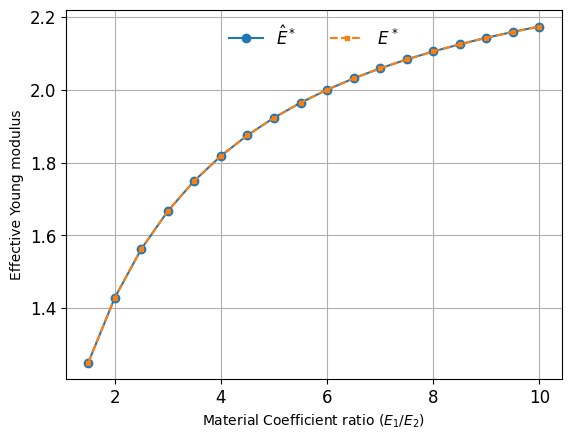

In [22]:
import pandas as pd
save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
N = 10

#pd.set_option('display.precision', 8)
#pd.set_option('display.float_format', lambda x: f"{x:.10e}")
df_summary = pd.DataFrame(table_rows)
df_summary['R1ₑ (%)'] = df_summary['Rₑ (%)'].map(lambda x: f"{x:.2e}%")
df_summary.to_csv(os.path.join(save_dir, f'table_{date}.csv'), index=False)
print(df_summary.to_string(index=False))

df_show = df_summary.copy()
df_show['C_eff_pred']  = df_show['C_eff_pred'].map(lambda x: f"{x:.10f}")
df_show['C_eff_exact'] = df_show['C_eff_exact'].map(lambda x: f"{x:.10f}")
#df_show['R1ₑ (%)']     = df_show['R1ₑ (%)'].map(lambda x: f"{x:.10f}")

print(df_show.to_string(index=False))


#coeficientes efectivos
plt.figure()
plt.plot(df_summary['E1/E2'], df_summary['C_eff_pred'], 'o-', label=f'$\hat{{E}}^*$')
plt.plot(df_summary['E1/E2'], df_summary['C_eff_exact'], 's--', label=f'${{E}}^*$', markersize=2.2)
plt.xlabel(r'Material Coefficient ratio $(E_1/E_2)$')
plt.ylabel('Effective Young modulus')
plt.legend(loc='upper center', ncol=4, frameon=False)
plt.grid(True)
outname = os.path.join(save_dir, f'Ceff vs cmat_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.show()

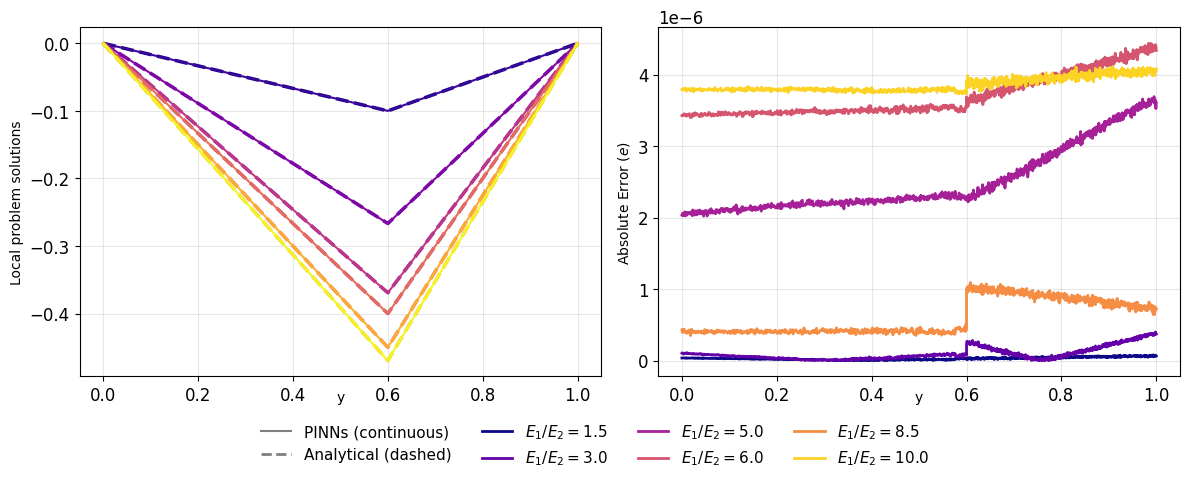

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

cmap = plt.get_cmap('plasma')
cmats = [1.5, 3.0, 5.0, 6.0, 8.5, 10.0]
colors = cmap(np.linspace(0, 1, 2*len(cmats)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

i = 0
for c in cmats:
    # trazos en el subplot izquierdo: analytical (dashed) y pinns (solid)
    axes[0].plot(points_y[c], N_analy[c], linestyle='--', linewidth=2.5,
                 color=colors[i+0])
    axes[0].plot(points_y[c], N_pinns[c], linestyle='-', linewidth=1.5,
                 color=colors[i+1])

    # trazo del error en el subplot derecho (una curva por c)
    error = np.abs(N_pinns[c] - N_analy[c])
    axes[1].plot(points_y[c], error, linewidth=2, color=colors[i], label=f'$E_1/E_2$={c}')
    i += 2

axes[0].set_xlabel('y', labelpad=-10)
axes[0].set_ylabel('Local problem solutions')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('y', labelpad=-10)
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].set_ylabel('Absolute Error ($e$)')
axes[1].grid(True, alpha=0.3)

legend_handles = []
legend_handles.append(Line2D([0], [0], color='gray', linestyle='-',  linewidth=1.5, label='PINNs (continuous)'))
legend_handles.append(Line2D([0], [0], color='gray', linestyle='--', linewidth=2,   label='Analytical (dashed)'))

i = 0
for c in cmats:
    legend_handles.append(
        Line2D([0], [0], color=colors[i], linewidth=2, label=f'$E_1/E_2={c}$'))
    i += 2

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,
    frameon=False,
    borderaxespad=1.0,
    fontsize=11
)

plt.tight_layout(rect=(0, 0.15, 1, 1))
outname = os.path.join(save_dir, f'pseudo_disp_analytical_vs_pinns_for_various_cmat1_vf_{vf}_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.show()


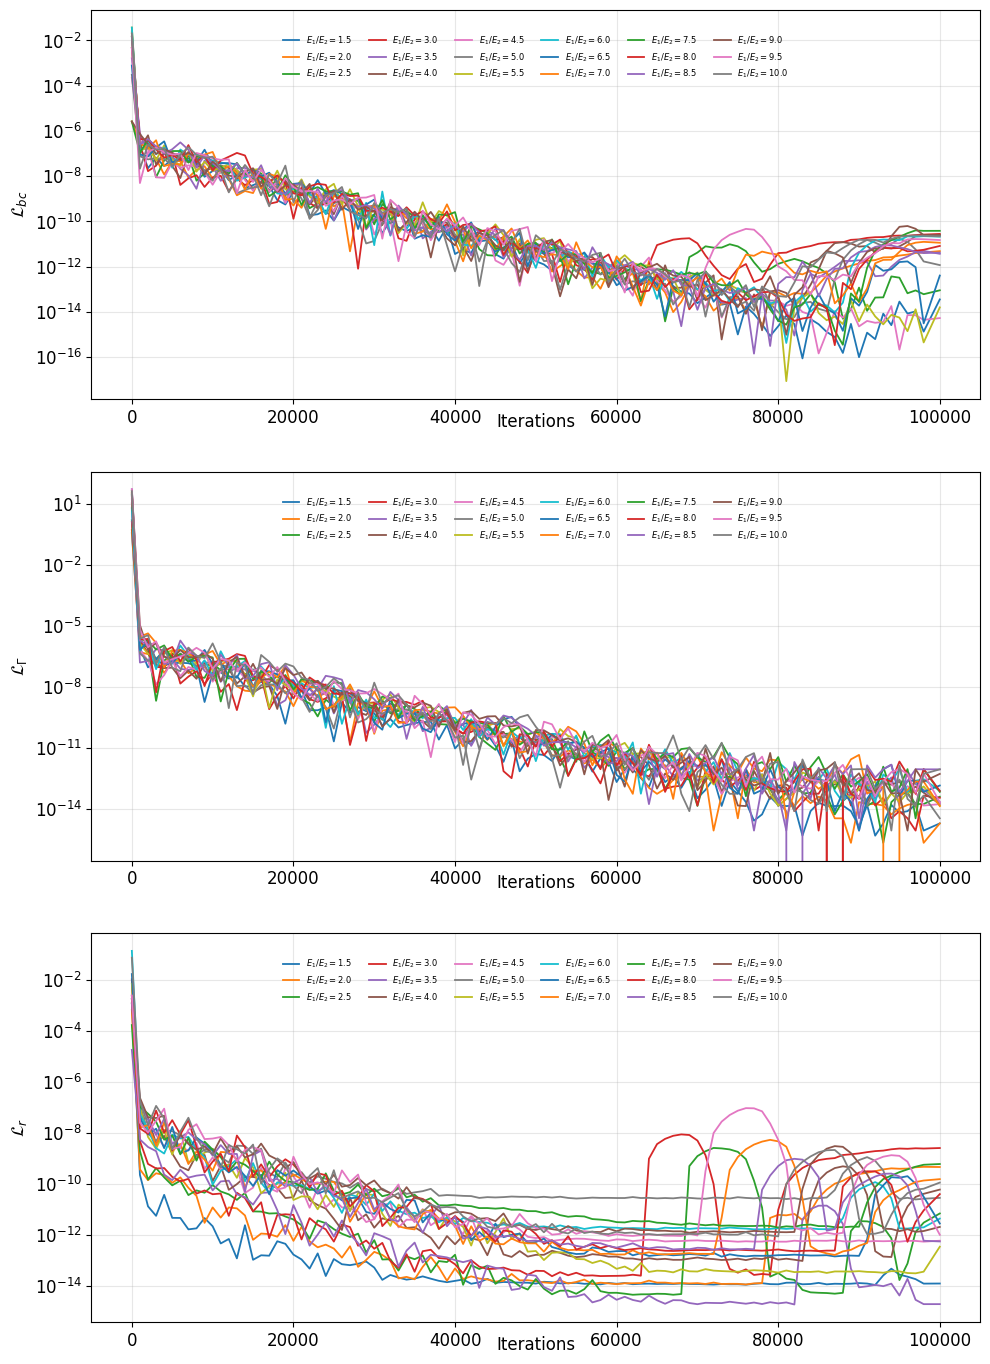

In [27]:
loss_types = ["bc_loss", "interface_loss", "collocation_loss"]
loss_str = [r'$\mathcal{L}_{bc}$', r'$\mathcal{L}_{\Gamma}$', r'$\mathcal{L}_{r}$']

files = [
    'table_losses_total_col_bc_interf2025_11_23_1.5.csv', 'table_losses_total_col_bc_interf2025_11_23_2.0.csv',
    'table_losses_total_col_bc_interf2025_11_23_2.5.csv', 'table_losses_total_col_bc_interf2025_11_23_3.0.csv',
    'table_losses_total_col_bc_interf2025_11_23_3.5.csv', 'table_losses_total_col_bc_interf2025_11_23_4.0.csv',
    'table_losses_total_col_bc_interf2025_11_23_4.5.csv', 'table_losses_total_col_bc_interf2025_11_23_5.0.csv',
    'table_losses_total_col_bc_interf2025_11_23_5.5.csv', 'table_losses_total_col_bc_interf2025_11_23_6.0.csv',
    'table_losses_total_col_bc_interf2025_11_23_6.5.csv', 'table_losses_total_col_bc_interf2025_11_23_7.0.csv',
    'table_losses_total_col_bc_interf2025_11_23_7.5.csv', 'table_losses_total_col_bc_interf2025_11_23_8.0.csv',
    'table_losses_total_col_bc_interf2025_11_23_8.5.csv', 'table_losses_total_col_bc_interf2025_11_23_9.0.csv',
    'table_losses_total_col_bc_interf2025_11_23_9.5.csv', 'table_losses_total_col_bc_interf2025_11_23_10.0.csv'
]

save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
file_paths = [os.path.join(save_dir, f) for f in files]

ratios = [
    '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5', '6.0',
    '6.5', '7.0', '7.5', '8.0', '8.5', '9.0', '9.5', '10.0'
]

# Crear figura con 3 subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(3, 1, figsize=(10, 14))

for ax, loss_name, loss_label in zip(axes, loss_types, loss_str):

    for fname, rt in zip(file_paths, ratios):
        df = pd.read_csv(fname)
        epochs_rel = list(range(len(df[loss_name]))) #multiplicarlos 1000
        epochs = [x * 1000+1 for x in epochs_rel]
        epochs[-1] = 99999

        ax.plot(
            epochs,
            df[loss_name],
            linewidth=1.3,
            label=rf'$E_1/E_2={rt}$'
        )

    ax.set_xlabel("Iterations", labelpad=-10, fontsize=12)
    ax.set_ylabel(loss_label, fontsize=12)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower center',
              ncol=6,
              fontsize=6,
              frameon=False,
              bbox_to_anchor=(0.5, 0.80))

plt.subplots_adjust(hspace=2)
plt.tight_layout()
outname = os.path.join(save_dir, f'training_losses_for_different_ratios_{vf}_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.show()



['/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_1.5.csv', '/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_2.0.csv', '/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_2.5.csv', '/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_3.0.csv', '/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_3.5.csv', '/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_4.0.csv', '/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_4.5.csv', '/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_5.0.csv', '/content/drive/My Drive/pinns/Laminado1D/save_soap1/table_losses_total_col_bc_interf2025_11_23_5.5.csv', '/content/drive/My Drive/pinns/Laminado1D/sav

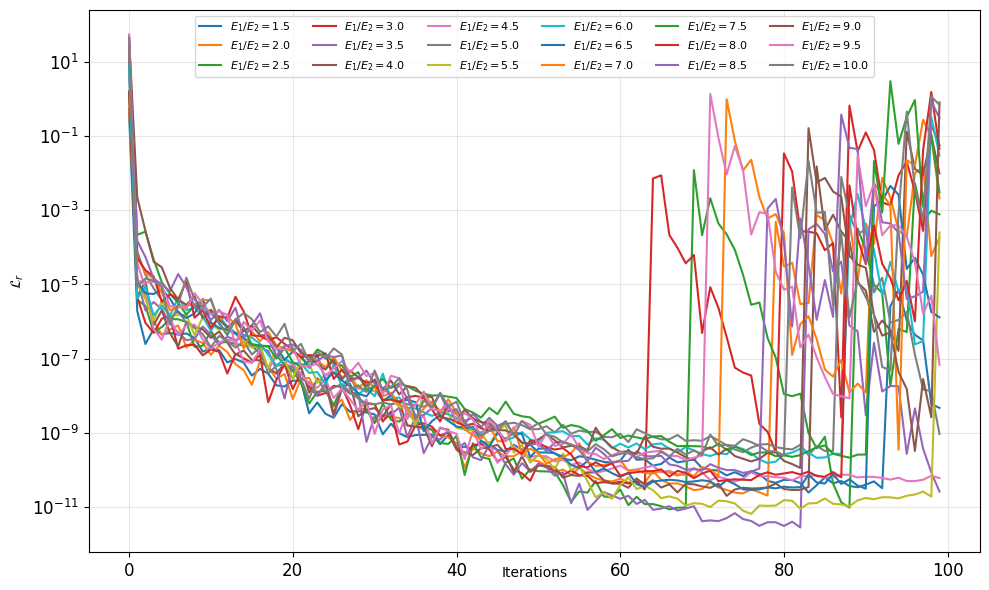

In [25]:
loss_name = "total_loss"
loss_str = r'$\mathcal{L}$'
files = ['table_losses_total_col_bc_interf2025_11_23_1.5.csv', 'table_losses_total_col_bc_interf2025_11_23_2.0.csv',
         'table_losses_total_col_bc_interf2025_11_23_2.5.csv', 'table_losses_total_col_bc_interf2025_11_23_3.0.csv',
         'table_losses_total_col_bc_interf2025_11_23_3.5.csv', 'table_losses_total_col_bc_interf2025_11_23_4.0.csv',
         'table_losses_total_col_bc_interf2025_11_23_4.5.csv', 'table_losses_total_col_bc_interf2025_11_23_5.0.csv',
         'table_losses_total_col_bc_interf2025_11_23_5.5.csv', 'table_losses_total_col_bc_interf2025_11_23_6.0.csv',
         'table_losses_total_col_bc_interf2025_11_23_6.5.csv', 'table_losses_total_col_bc_interf2025_11_23_7.0.csv',
         'table_losses_total_col_bc_interf2025_11_23_7.5.csv', 'table_losses_total_col_bc_interf2025_11_23_8.0.csv',
         'table_losses_total_col_bc_interf2025_11_23_8.5.csv', 'table_losses_total_col_bc_interf2025_11_23_9.0.csv',
         'table_losses_total_col_bc_interf2025_11_23_9.5.csv', 'table_losses_total_col_bc_interf2025_11_23_10.0.csv']


save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
file_paths = [os.path.join(save_dir, f) for f in files]
print(file_paths)

ratios = ['1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5', '6.0', '6.5', '7.0', '7.5',
          '8.0', '8.5', '9.0', '9.5', '10.0']

plt.figure(figsize=(10, 6))

for fname, rt in zip(file_paths, ratios):
    df = pd.read_csv(fname)
    label_name = r'$E_1/E_2 = $' + rt
    epochs = list(range(len(df[loss_name])))

    plt.plot(
        epochs,
        df[loss_name],
        label=label_name,
        linewidth=1.5)

plt.xlabel("Iterations", labelpad=-10)
plt.ylabel(loss_label)
plt.yscale("log")  # quítalo si no quieres escala log
plt.grid(True, alpha=0.3)
plt.legend(loc='upper center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, 1.0),)
plt.tight_layout()
outname = os.path.join(save_dir, f'training_total_loss_for_different_ratios_{vf}_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.show()